#  Oráculo del Balón — Mundial 2026
## Notebook 02: EDA y Limpieza de Datos

### ¿Qué hacemos aquí?
Transformamos los datos crudos de 8 fuentes en un dataset limpio
y unificado listo para el modelo de Machine Learning.

**Pasos:**
1. Cargar cada fuente y diagnosticar problemas
2. Estandarizar nombres de selecciones
3. Limpiar nulos, duplicados y formatos
4. Aplicar Time Decay (peso por antigüedad)
5. Visualizar patrones (EDA)
6. Guardar datasets limpios en `data/processed/`

### Fuentes utilizadas
| Fuente | Archivo | Registros |
|--------|---------|-----------|
| martj42 | results.csv | 49,329 partidos |
| FIFA Rankings | ranking_*.csv | Rankings históricos |
| WC History | matches_1930_2022.csv | 964 partidos |
| Transfermarkt | squad_values.json | Valores plantilla |
| World Bank | world_bank_indicators.json | Indicadores socioeconómicos |
| Football-data.org | leagues/*.json | Plantillas top 6 ligas |
| Convocados | convocados_wc2026.json | 48 selecciones WC2026 |

In [3]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================

import pandas as pd        # manejo de tablas/DataFrames
import numpy as np         # operaciones matemáticas
import matplotlib.pyplot as plt   # gráficas
import matplotlib.ticker as mticker
import seaborn as sns      # gráficas estadísticas
import json                # leer archivos .json
import warnings
from pathlib import Path   # manejo de rutas

warnings.filterwarnings('ignore')

# Configuración de pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Rutas del proyecto ───────────────────────────────────────
ROOT     = Path('..')                    # sube de notebooks/ a la raíz
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PRO = ROOT / 'data' / 'processed'
FIGURES  = ROOT / 'reports' / 'figures'

# Crear carpetas si no existen
DATA_PRO.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("✅ Librerías cargadas")
print(f"📁 raw       → {DATA_RAW.resolve()}")
print(f"📁 processed → {DATA_PRO.resolve()}")
print(f"📁 figures   → {FIGURES.resolve()}")

✅ Librerías cargadas
📁 raw       → /Users/jpurquilla/Desktop/UES-ML/oraculo-mundial2026/data/raw
📁 processed → /Users/jpurquilla/Desktop/UES-ML/oraculo-mundial2026/data/processed
📁 figures   → /Users/jpurquilla/Desktop/UES-ML/oraculo-mundial2026/reports/figures


---
## 1. Diagnóstico Inicial de Fuentes

Antes de limpiar necesitamos entender qué tenemos.
La función `quick_report()` nos dará por cada dataset:
- Cuántas filas y columnas tiene
- Qué columnas tienen valores nulos
- Si hay filas duplicadas
- Qué tipo de dato tiene cada columna

In [4]:
def quick_report(df: pd.DataFrame, nombre: str) -> None:
    """
    Imprime un resumen de calidad de un DataFrame.
    
    Parámetros:
        df     : El DataFrame a analizar
        nombre : Nombre descriptivo para mostrar
    """
    print(f"\n{'='*60}")
    print(f"  📊  {nombre}")
    print(f"{'='*60}")
    
    # Cuántas filas y columnas tiene
    print(f"  Tamaño   : {df.shape[0]:,} filas  ×  {df.shape[1]} columnas")
    
    # Columnas con valores nulos
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"  ⚠️  Nulos  : {dict(nulos)}")
    else:
        print(f"  Nulos    : ninguno ✅")
    
    # Filas exactamente iguales
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  ⚠️  Duplic : {duplicados:,} filas duplicadas")
    else:
        print(f"  Duplic.  : ninguno ✅")
    
    # Tipos de datos por columna
    print(f"  Columnas :")
    for col in df.columns:
        nulos_col = df[col].isnull().sum()
        pct = nulos_col / len(df) * 100
        marca = f" ⚠️  {pct:.1f}% nulos" if nulos_col > 0 else ""
        print(f"    - {col:<40} {str(df[col].dtype):<10}{marca}")
    
    # Primeras 3 filas
    print(f"\n  Primeras 3 filas:")
    print(df.head(3).to_string())

print("✅ Función quick_report definida")

✅ Función quick_report definida


---
## 2. Carga y Limpieza de Datos

### 2.1 Resultados Históricos — `results.csv`

Nuestra fuente principal con 49,257 partidos internacionales desde 1872 hasta 2026.
Cada fila representa un partido con equipos, marcador y tipo de torneo.

**Importante:** El dataset incluye los 72 partidos de la fase de grupos 
del Mundial 2026 ya programados pero sin resultados (NaN). 
Estos los separaremos como dataset de predicción, NO de entrenamiento.

También separaremos los 64 partidos del Mundial 2022 para usar como
dataset de evaluación del modelo.

**Problemas encontrados:**
- 72 filas sin marcador → son los partidos futuros del WC2026
- `date` en formato texto → convertir a fecha real
- `home_score` y `away_score` en float64 → convertir a entero
- Nombres de selecciones inconsistentes entre fuentes

In [9]:
# ============================================================
# SEPARAR partidos futuros (Mundial 2026) del dataset
# de entrenamiento
# ============================================================

# Cargar el archivo CSV
df_results = pd.read_csv(DATA_RAW / 'matches' / 'results.csv')

# Diagnóstico inicial
quick_report(df_results, "results.csv — Partidos internacionales 1872-2026")

# ── Convertir fecha ──────────────────────────────────────────
df_results['date'] = pd.to_datetime(df_results['date'])

# ── Separar en 3 datasets ────────────────────────────────────

# 1. Partidos futuros = fase de grupos WC2026 (sin resultados)
df_wc2026_grupos = df_results[df_results['home_score'].isna()].copy()
df_wc2026_grupos = df_wc2026_grupos.reset_index(drop=True)

# 2. Solo partidos jugados
df_jugados = df_results[df_results['home_score'].notna()].copy()

# 3. Mundial 2022 → para EVALUAR el modelo (separar ANTES de entrenar)
df_wc2022_eval = df_jugados[
    (df_jugados['tournament'] == 'FIFA World Cup') &
    (df_jugados['date'].dt.year == 2022)
].copy().reset_index(drop=True)

# 4. Dataset de entrenamiento = todo lo demás
df_results_train = df_jugados[
    ~((df_jugados['tournament'] == 'FIFA World Cup') &
      (df_jugados['date'].dt.year == 2022))
].copy().reset_index(drop=True)

# ── Resumen ──────────────────────────────────────────────────
print(f"\n{'='*45}")
print(f"  SEPARACIÓN DE DATASETS")
print(f"{'='*45}")
print(f"  Total partidos         : {len(df_results):,}")
print(f"  ├── Para ENTRENAR      : {len(df_results_train):,}")
print(f"  ├── Para EVALUAR WC2022: {len(df_wc2022_eval)}")
print(f"  └── Para PREDECIR WC2026: {len(df_wc2026_grupos)}")

# ── Guardar ──────────────────────────────────────────────────
df_results_train.to_csv(DATA_PRO / 'results_train.csv',    index=False)
df_wc2022_eval.to_csv(DATA_PRO  / 'wc2022_eval.csv',       index=False)
df_wc2026_grupos.to_csv(DATA_PRO / 'wc2026_grupos.csv',    index=False)

print(f"\n✅ Guardados en data/processed/:")
print(f"   results_train.csv   → entrenamiento")
print(f"   wc2022_eval.csv     → evaluación del modelo")
print(f"   wc2026_grupos.csv   → predicción final")


  📊  results.csv — Partidos internacionales 1872-2026
  Tamaño   : 49,329 filas  ×  9 columnas
  ⚠️  Nulos  : {'home_score': 72, 'away_score': 72}
  Duplic.  : ninguno ✅
  Columnas :
    - date                                     object    
    - home_team                                object    
    - away_team                                object    
    - home_score                               float64    ⚠️  0.1% nulos
    - away_score                               float64    ⚠️  0.1% nulos
    - tournament                               object    
    - city                                     object    
    - country                                  object    
    - neutral                                  bool      

  Primeras 3 filas:
         date home_team away_team  home_score  away_score tournament     city   country  neutral
0  1872-11-30  Scotland   England       0.000       0.000   Friendly  Glasgow  Scotland    False
1  1873-03-08   England  Scotland       4.000    

### 2.2 Estandarización de Nombres de Selecciones

Cada fuente usa nombres distintos para el mismo equipo:
- `results.csv` usa "United States" 
- `convocados.json` usa nombres en español ("Alemania", "Francia")
- Otras fuentes usan "Korea Republic" en vez de "South Korea"

**Estrategia:** Usamos como nombres estándar los que tiene
`results.csv` para los 48 equipos del WC2026. El diccionario
mapea cualquier variante al nombre estándar.

Fuente de verdad para los 48 equipos: `wc2026_grupos.csv`

In [32]:
# ============================================================
# SECCIÓN 2.2 - ESTANDARIZACIÓN DE NOMBRES DE SELECCIONES
# Nombres estándar = los que usa results.csv para WC2026
# El diccionario mapea nombres ALTERNATIVOS al estándar
# ============================================================

TEAM_NAME_MAP = {
    # ── Nombres en español (convocados.json) ─────────────────
    'Alemania':              'Germany',
    'Bélgica':               'Belgium',
    'Bosnia y Herzegovina':  'Bosnia and Herzegovina',
    'Brasil':                'Brazil',
    'Cabo Verde':            'Cape Verde',
    'Corea del Sur':         'South Korea',
    'Costa de Marfil':       'Ivory Coast',
    'Croacia':               'Croatia',
    'Curazao':               'Curaçao',
    'Francia':               'France',
    'Japón':                 'Japan',
    'México':                'Mexico',
    'Nueva Zelanda':         'New Zealand',
    'RD Congo':              'DR Congo',
    'Suecia':                'Sweden',
    'Suiza':                 'Switzerland',
    'Túnez':                 'Tunisia',

    # ── Nombres alternativos en inglés (otras fuentes) ───────
    'United States':             'USA',
    'United States of America':  'USA',
    'Korea Republic':            'South Korea',
    'Korea DPR':                 'North Korea',
    'China PR':                  'China',
    'Czech Republic':            'Czechia',
    'Republic of Ireland':       'Ireland',
    'IR Iran':                   'Iran',
    'Türkiye':                   'Turkey',
    'Turkiye':                   'Turkey', 
    'Turkiye':                   'Turkey',
    'FYR Macedonia':             'North Macedonia',
    "Côte d'Ivoire":             'Ivory Coast',
    'Trinidad and Tobago':       'Trinidad & Tobago',
    'Congo DR':                  'DR Congo',
    'Bosnia-Herzegovina':        'Bosnia and Herzegovina',

}

def normalize_team(name: str) -> str:
    """
    Estandariza el nombre de una selección nacional.
    Nombre estándar = el que usa results.csv para WC2026.
    Si no está en el mapa lo devuelve sin cambios.

    Ejemplos:
        normalize_team("United States") → "USA"
        normalize_team("Brasil")        → "Brazil"
        normalize_team("France")        → "France"  (sin cambio)
        normalize_team("Alemania")      → "Germany"
    """
    if not isinstance(name, str):
        return name
    return TEAM_NAME_MAP.get(name.strip(), name.strip())

# ── Verificar los 48 equipos del WC2026 ──────────────────────
equipos_wc2026 = sorted(pd.concat([
    df_wc2026_grupos['home_team'],
    df_wc2026_grupos['away_team']
]).unique())

print(f"Total equipos WC2026: {len(equipos_wc2026)}")
print("\nVerificando nombres:")
cambios = 0
for i, equipo in enumerate(equipos_wc2026, 1):
    normalizado = normalize_team(equipo)
    if normalizado != equipo:
        print(f"  {i:>2}. ✅ '{equipo}' → '{normalizado}'")
        cambios += 1
    else:
        print(f"  {i:>2}. ✓  '{equipo}'")

print(f"\n✅ Diccionario listo: {len(TEAM_NAME_MAP)} mappings")
print(f"   Equipos que cambian nombre: {cambios}")
print(f"   Equipos sin cambio        : {len(equipos_wc2026) - cambios}")

# ── Aplicar normalización a todos los datasets ───────────────
print("\nAplicando normalización a todos los datasets...")

for df, nombre in [
    (df_results_train, 'results_train'),
    (df_wc2022_eval,   'wc2022_eval'),
    (df_wc2026_grupos, 'wc2026_grupos'),
]:
    df['home_team'] = df['home_team'].apply(normalize_team)
    df['away_team'] = df['away_team'].apply(normalize_team)
    print(f"  ✅ {nombre} normalizado")

# ── Verificar que United States ya es USA ────────────────────
print("\nVerificación USA en results_train (últimos 5 partidos):")
verificar = df_results_train[
    df_results_train['home_team'].isin(['United States', 'USA']) |
    df_results_train['away_team'].isin(['United States', 'USA'])
][['date', 'home_team', 'away_team']].tail(5)
print(verificar.to_string())

print("\nVerificación USA en wc2026_grupos:")
usa_wc = df_wc2026_grupos[
    (df_wc2026_grupos['home_team'] == 'USA') |
    (df_wc2026_grupos['away_team'] == 'USA')
][['date', 'home_team', 'away_team']]
print(usa_wc.to_string())

# ── Guardar datasets actualizados ────────────────────────────
df_results_train.to_csv(DATA_PRO / 'results_train.csv',  index=False)
df_wc2022_eval.to_csv(DATA_PRO   / 'wc2022_eval.csv',    index=False)
df_wc2026_grupos.to_csv(DATA_PRO / 'wc2026_grupos.csv',  index=False)

print("\n✅ Datasets guardados con nombres estandarizados:")
print("   results_train.csv")
print("   wc2022_eval.csv")
print("   wc2026_grupos.csv")

# Recalcular equipos_wc2026 con nombres normalizados
equipos_wc2026 = sorted(pd.concat([
    df_wc2026_grupos['home_team'],
    df_wc2026_grupos['away_team']
]).unique())

print(f"Equipos WC2026 actualizados: {len(equipos_wc2026)}")
print(equipos_wc2026)

Total equipos WC2026: 48

Verificando nombres:
   1. ✓  'Algeria'
   2. ✓  'Argentina'
   3. ✓  'Australia'
   4. ✓  'Austria'
   5. ✓  'Belgium'
   6. ✓  'Bosnia and Herzegovina'
   7. ✓  'Brazil'
   8. ✓  'Canada'
   9. ✓  'Cape Verde'
  10. ✓  'Colombia'
  11. ✓  'Croatia'
  12. ✓  'Curaçao'
  13. ✓  'Czechia'
  14. ✓  'DR Congo'
  15. ✓  'Ecuador'
  16. ✓  'Egypt'
  17. ✓  'England'
  18. ✓  'France'
  19. ✓  'Germany'
  20. ✓  'Ghana'
  21. ✓  'Haiti'
  22. ✓  'Iran'
  23. ✓  'Iraq'
  24. ✓  'Ivory Coast'
  25. ✓  'Japan'
  26. ✓  'Jordan'
  27. ✓  'Mexico'
  28. ✓  'Morocco'
  29. ✓  'Netherlands'
  30. ✓  'New Zealand'
  31. ✓  'Norway'
  32. ✓  'Panama'
  33. ✓  'Paraguay'
  34. ✓  'Portugal'
  35. ✓  'Qatar'
  36. ✓  'Saudi Arabia'
  37. ✓  'Scotland'
  38. ✓  'Senegal'
  39. ✓  'South Africa'
  40. ✓  'South Korea'
  41. ✓  'Spain'
  42. ✓  'Sweden'
  43. ✓  'Switzerland'
  44. ✓  'Tunisia'
  45. ✓  'Turkey'
  46. ✓  'USA'
  47. ✓  'Uruguay'
  48. ✓  'Uzbekistan'

✅ Diccionar

### 2.3 Limpieza de results_train

Con los partidos separados y nombres estandarizados, ahora limpiamos
el dataset de entrenamiento:

- Convertir `home_score` y `away_score` de float a entero
- Crear columna `result` con el resultado del partido (H/D/A)
- Aplicar Time Decay (peso exponencial por antigüedad)
- Filtrar desde 1993 (cuando inicia el ranking FIFA)

**Resultado esperado (H/D/A):**
- H = Home wins (local gana)
- D = Draw (empate)
- A = Away wins (visitante gana)

### 2.3.1 Time Decay — Justificación Técnica

#### ¿Por qué aplicar decaimiento temporal?
Un partido de Francia en 2010 tiene poco valor predictivo para 2026.
Los equipos cambian: nuevos jugadores, nuevo técnico, nueva táctica.
Necesitamos que el modelo **aprenda más de lo reciente** y 
**olvide gradualmente lo antiguo**.

#### Fórmula utilizada
La función de decaimiento exponencial es estándar en modelos deportivos:

w = 0.5 ^ (días_atrás / half_life)

Donde:
- `w` = peso del partido (entre 0 y 1)
- `días_atrás` = días desde el partido hasta la fecha de corte
- `half_life` = 1,095 días (3 años)

#### ¿Por qué base 0.5?
Significa que cada período (half_life) el peso se reduce a la mitad.
Es intuitivo y estándar en modelos de decaimiento:

| Antigüedad | Cálculo | Peso |
|------------|---------|------|
| Hoy | 0.5^0 | 1.00 (100%) |
| 3 años | 0.5^1 | 0.50 (50%) |
| 6 años | 0.5^2 | 0.25 (25%) |
| 9 años | 0.5^3 | 0.13 (13%) |

#### ¿Por qué half_life de 3 años?
Es un ciclo completo de selección nacional:
- Clasificatorias (2 años) + preparación para el Mundial (1 año)
- Menos de 2 años → demasiado agresivo, se descartan datos útiles
- Más de 5 años → demasiado suave, partidos de hace 8 años pesan casi igual

#### Fecha de corte: 10 de junio de 2026
Un día antes del primer partido del Mundial. Así aprovechamos
todos los datos disponibles incluyendo eliminatorias 2025-2026
sin incluir partidos del propio torneo.


In [14]:
# ============================================================
# SECCIÓN 2.3 - LIMPIEZA DE RESULTS_TRAIN
# ============================================================

df_r = df_results_train.copy()

# PASO 1: Convertir scores de float a entero
# (vienen como 2.0, 1.0 en vez de 2, 1)
df_r['home_score'] = df_r['home_score'].astype(int)
df_r['away_score'] = df_r['away_score'].astype(int)

# PASO 2: Crear columna resultado desde perspectiva del local
# H = local gana, A = visitante gana, D = empate
condiciones = [
    df_r['home_score'] > df_r['away_score'],
    df_r['home_score'] < df_r['away_score'],
    df_r['home_score'] == df_r['away_score'],
]
df_r['result'] = np.select(condiciones, ['H', 'A', 'D'], default='D')

# PASO 3: Filtrar desde 1993
# Antes de 1993 no hay ranking FIFA, los datos tienen menos valor
antes = len(df_r)
df_r = df_r[df_r['date'].dt.year >= 1993].copy().reset_index(drop=True)
print(f"Partidos eliminados pre-1993 : {antes - len(df_r):,}")
print(f"Partidos restantes           : {len(df_r):,}")

# PASO 4: Time Decay — peso exponencial por antigüedad
# Fórmula: w = 0.5 ^ (días_atrás / half_life)
# - Partido de hoy      → peso 1.00
# - Hace 3 años         → peso 0.50
# - Hace 6 años         → peso 0.25
FECHA_CORTE = pd.Timestamp('2026-06-10')
HALF_LIFE   = 3 * 365  # 3 años en días

def time_decay_weight(fecha: pd.Timestamp) -> float:
    """
    Calcula el peso de un partido según su antigüedad.
    Fórmula: w = 0.5 ^ (días_atrás / half_life)
    """
    dias_atras = (FECHA_CORTE - fecha).days
    if dias_atras < 0:
        return 1.0
    return 0.5 ** (dias_atras / HALF_LIFE)

df_r['time_weight'] = df_r['date'].apply(time_decay_weight)

# PASO 5: Resumen de distribución de resultados
print(f"\nDistribución de resultados:")
conteo = df_r['result'].value_counts()
total  = len(df_r)
for resultado, cantidad in conteo.items():
    etiqueta = {'H': 'Local gana', 'D': 'Empate', 'A': 'Visitante gana'}[resultado]
    barra = '█' * int(cantidad / total * 40)
    print(f"  {etiqueta:<15} {barra} {cantidad:,} ({cantidad/total*100:.1f}%)")

# PASO 6: Ejemplos de pesos por año
print(f"\nEjemplos de Time Decay:")
for año in [2025, 2024, 2022, 2020, 2018, 2015, 2010, 2000]:
    w = time_decay_weight(pd.Timestamp(f'{año}-06-01'))
    barra = '█' * int(w * 20)
    print(f"  {año}: {barra:<20} {w:.3f}")

# PASO 7: Guardar
df_r.to_csv(DATA_PRO / 'results_clean.csv', index=False)
print(f"\n✅ Guardado: data/processed/results_clean.csv")
print(f"   Shape final: {df_r.shape}")
print(f"\n  Columnas:")
print(df_r.dtypes.to_string())

Partidos eliminados pre-1993 : 18,707
Partidos restantes           : 30,486

Distribución de resultados:
  Local gana      ███████████████████ 14,795 (48.5%)
  Visitante gana  ███████████ 8,580 (28.1%)
  Empate          █████████ 7,111 (23.3%)

Ejemplos de Time Decay:
  2025: ███████████████      0.789
  2024: ████████████         0.626
  2022: ███████              0.394
  2020: ████                 0.248
  2018: ███                  0.156
  2015: █                    0.078
  2010:                      0.025
  2000:                      0.002

✅ Guardado: data/processed/results_clean.csv
   Shape final: (30486, 11)

  Columnas:
date           datetime64[ns]
home_team              object
away_team              object
home_score              int64
away_score              int64
tournament             object
city                   object
country                object
neutral                  bool
result                 object
time_weight           float64


### 2.3.2 EDA Visual — Resultados Históricos

Visualizamos los patrones principales del dataset de entrenamiento.
Estas gráficas formarán parte del reporte técnico final.

✅ Gráfica guardada en reports/figures/eda_overview.png


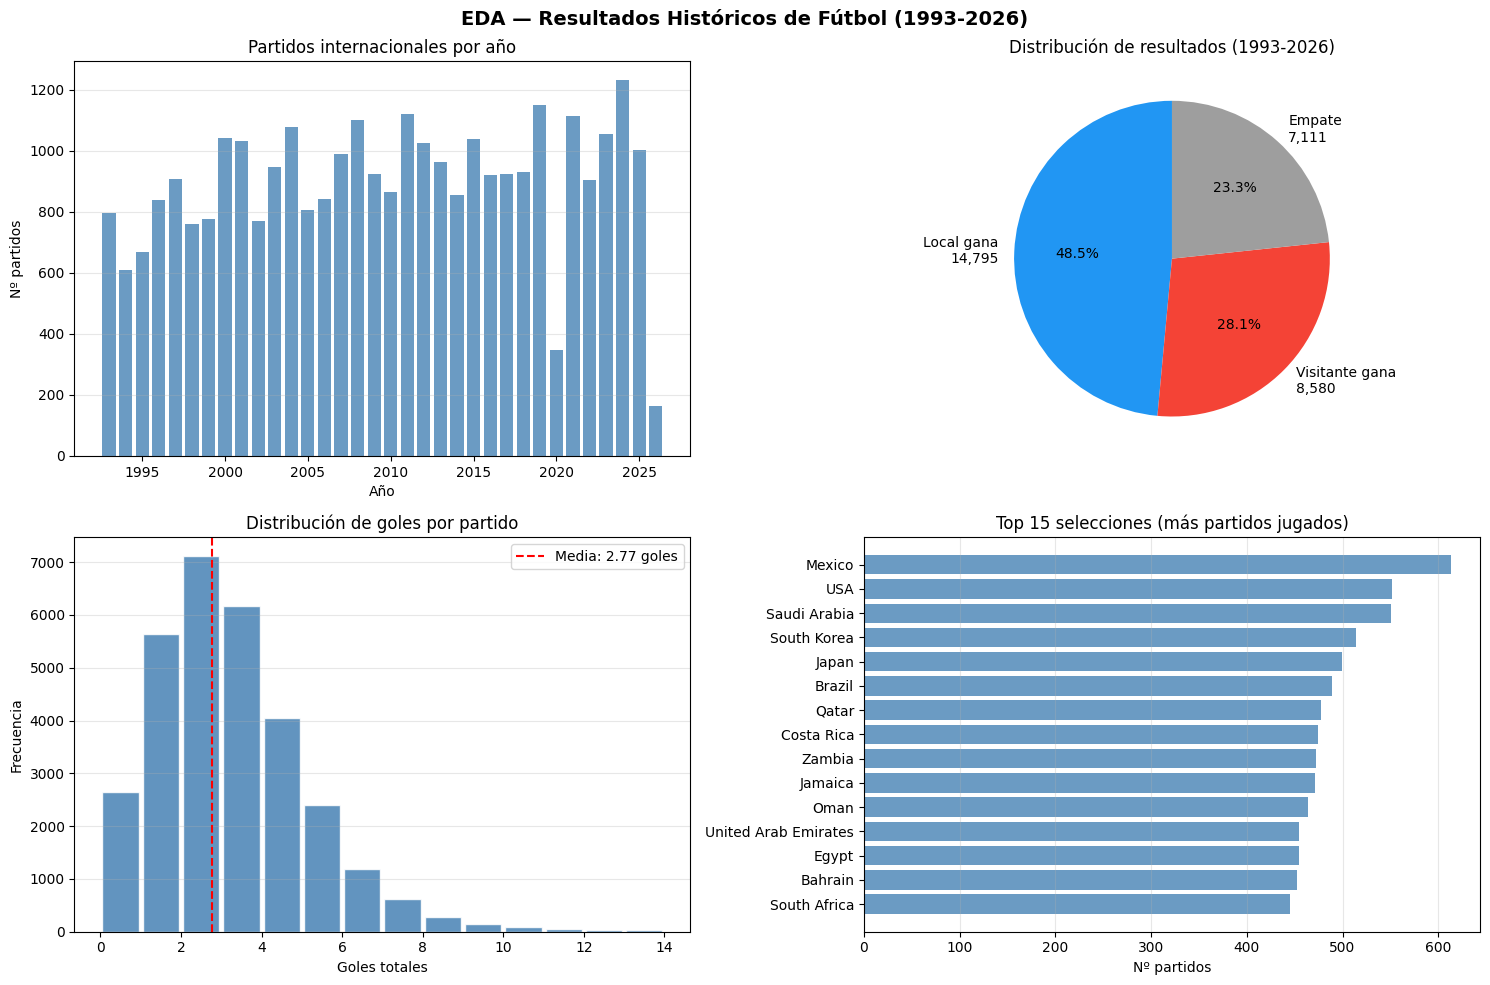

In [17]:
# ============================================================
# SECCIÓN 2.3.2 - EDA VISUAL
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('EDA — Resultados Históricos de Fútbol (1993-2026)',
             fontsize=14, fontweight='bold')

# ── Gráfica 1: Partidos por año ──────────────────────────────
ax = axes[0, 0]
partidos_año = df_r.groupby(df_r['date'].dt.year).size()
ax.bar(partidos_año.index, partidos_año.values, color='steelblue', alpha=0.8)
ax.set_title('Partidos internacionales por año')
ax.set_xlabel('Año')
ax.set_ylabel('Nº partidos')
ax.grid(axis='y', alpha=0.3)

# ── Gráfica 2: Distribución de resultados ───────────────────
ax = axes[0, 1]
conteo = df_r['result'].value_counts()
colores = {'H': '#2196F3', 'D': '#9E9E9E', 'A': '#F44336'}
etiquetas = {'H': f"Local gana\n{conteo['H']:,}", 
             'D': f"Empate\n{conteo['D']:,}", 
             'A': f"Visitante gana\n{conteo['A']:,}"}
ax.pie(
    conteo,
    labels=[etiquetas[k] for k in conteo.index],
    colors=[colores[k] for k in conteo.index],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Distribución de resultados (1993-2026)')

# ── Gráfica 3: Distribución de goles por partido ─────────────
ax = axes[1, 0]
goles = df_r['home_score'] + df_r['away_score']
ax.hist(goles, bins=range(0, 15), color='steelblue',
        edgecolor='white', alpha=0.85, rwidth=0.9)
media = goles.mean()
ax.axvline(media, color='red', linestyle='--',
           label=f'Media: {media:.2f} goles')
ax.set_title('Distribución de goles por partido')
ax.set_xlabel('Goles totales')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Gráfica 4: Top 15 selecciones más activas ────────────────
ax = axes[1, 1]
todos = pd.concat([df_r['home_team'], df_r['away_team']])
top15 = todos.value_counts().head(15).sort_values()
ax.barh(top15.index, top15.values, color='steelblue', alpha=0.8)
ax.set_title('Top 15 selecciones (más partidos jugados)')
ax.set_xlabel('Nº partidos')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()### 2.4 Rankings FIFA


print("✅ Gráfica guardada en reports/figures/eda_overview.png")

### 2.3.3 Dataset Histórico para Cálculo de ELO

El ELO es acumulativo — debe calcularse desde 1872 para reflejar
la historia real de cada selección. Un equipo como Brasil que lleva
100 años de partidos tendrá un ELO muy diferente a San Marino.

Guardamos el dataset histórico completo (sin filtro de año) como
fuente exclusiva para el cálculo de ELO en el notebook 03.

**¿Por qué desde 1872 y no desde 1993?**
- Si empezamos en 1993 todos arrancan con ELO = 1500
- Brasil = 1500, San Marino = 1500 → sin diferencia histórica
- Desde 1872 Brasil acumula victorias reales → ELO ≈ 2100
- San Marino casi no gana → ELO ≈ 1200

**Archivos generados:**
- `results_historico_1872.csv` → INPUT para calcular ELO (notebook 03)
- `elo_ratings.csv` → OUTPUT del cálculo ELO (se genera en notebook 03)

In [20]:
# ============================================================
# SECCIÓN 2.3.3 - DATASET HISTÓRICO COMPLETO PARA ELO
# INPUT para el cálculo de ELO en notebook 03
# ============================================================

# Todos los partidos jugados desde 1872 (sin filtro de año)
df_results_historico = df_results[df_results['home_score'].notna()].copy()

# Convertir scores a entero
df_results_historico['home_score'] = df_results_historico['home_score'].astype(int)
df_results_historico['away_score'] = df_results_historico['away_score'].astype(int)

# Normalizar nombres
df_results_historico['home_team'] = df_results_historico['home_team'].apply(normalize_team)
df_results_historico['away_team'] = df_results_historico['away_team'].apply(normalize_team)

# Ordenar por fecha (crítico para ELO acumulativo)
df_results_historico = df_results_historico.sort_values('date').reset_index(drop=True)

# Guardar
df_results_historico.to_csv(DATA_PRO / 'results_historico_1872.csv', index=False)

print(f"✅ Guardado: data/processed/results_historico_1872.csv")
print(f"   Shape : {df_results_historico.shape}")
print(f"   Desde : {df_results_historico['date'].min().date()}")
print(f"   Hasta : {df_results_historico['date'].max().date()}")
print(f"   Torneos: {df_results_historico['tournament'].nunique()} tipos distintos")
print(f"\n   NOTA: Este archivo es el INPUT para calcular ELO en notebook 03")
print(f"   El ELO calculado se guardará en data/processed/elo_ratings.csv")

✅ Guardado: data/processed/results_historico_1872.csv
   Shape : (49257, 9)
   Desde : 1872-11-30
   Hasta : 2026-03-31
   Torneos: 198 tipos distintos

   NOTA: Este archivo es el INPUT para calcular ELO en notebook 03
   El ELO calculado se guardará en data/processed/elo_ratings.csv


### 2.4 Rankings FIFA

Consolidamos 4 snapshots de rankings FIFA en uno solo.
Necesitamos dos versiones:

- `ranking_clean.csv` → ranking más reciente (jun 2024) para entrenar y predecir WC2026
- `ranking_wc2022.csv` → ranking oct 2022 para validar el modelo con WC2022

**Archivos disponibles:**
- `fifa_ranking_2022-10-06.csv` → ranking previo al WC2022 (estructura diferente)
- `fifa_ranking-2023-07-20.csv` → ranking julio 2023
- `fifa_ranking-2024-04-04.csv` → ranking abril 2024
- `fifa_ranking-2024-06-20.csv` → ranking junio 2024 (más reciente)

**Problema:** El archivo de 2022 usa columna `team` en vez de `country_full`.
Lo normalizamos antes de consolidar.

In [24]:
# ============================================================
# SECCIÓN 2.4 - RANKINGS FIFA
# ============================================================

# ── PARTE A: Ranking más reciente (jun 2024) ─────────────────
# Para entrenar el modelo y predecir WC2026

df_rank_2023 = pd.read_csv(DATA_RAW / 'ranking' / 'fifa_ranking-2023-07-20.csv')
df_rank_apr  = pd.read_csv(DATA_RAW / 'ranking' / 'fifa_ranking-2024-04-04.csv')
df_rank_jun  = pd.read_csv(DATA_RAW / 'ranking' / 'fifa_ranking-2024-06-20.csv')

# Agregar columna de snapshot a cada uno
df_rank_2023['snapshot'] = 'jul_2023'
df_rank_apr['snapshot']  = 'apr_2024'
df_rank_jun['snapshot']  = 'jun_2024'

# Consolidar los 3 en uno
df_ranking_hist = pd.concat([df_rank_2023, df_rank_apr, df_rank_jun], ignore_index=True)

# Convertir rank_date a fecha real
df_ranking_hist['rank_date'] = pd.to_datetime(df_ranking_hist['rank_date'])

# Normalizar nombres
df_ranking_hist['country_full'] = df_ranking_hist['country_full'].apply(normalize_team)

# Quedarnos con el ranking más reciente por equipo
df_ranking_latest = (
    df_ranking_hist
    .sort_values('rank_date', ascending=False)
    .groupby('country_full')
    .first()
    .reset_index()
    [['country_full', 'country_abrv', 'rank', 'total_points', 'confederation']]
    .rename(columns={
        'country_full': 'team',
        'rank':         'fifa_rank',
        'total_points': 'fifa_points',
    })
)

# Convertir rank a entero
df_ranking_latest['fifa_rank'] = df_ranking_latest['fifa_rank'].fillna(999).astype(int)

print(f"✅ Rankings consolidados (jun 2024)")
print(f"   Total equipos con ranking: {len(df_ranking_latest)}")

print(f"\nTop 20 equipos por ranking FIFA:")
print(df_ranking_latest.sort_values('fifa_rank').head(20).to_string())

# ── Verificar los 48 equipos del WC2026 ──────────────────────
wc_rankings = df_ranking_latest[
    df_ranking_latest['team'].isin(equipos_wc2026)
].sort_values('fifa_rank')

print(f"\nRanking de los 48 equipos del WC2026:")
print(f"  Equipos WC2026 con ranking: {len(wc_rankings)}/48")
print(wc_rankings.to_string())

# Equipos sin ranking
sin_ranking = [e for e in equipos_wc2026
               if e not in df_ranking_latest['team'].values]
if sin_ranking:
    print(f"\n⚠️  Equipos WC2026 SIN ranking: {sin_ranking}")
else:
    print(f"\n✅ Todos los equipos WC2026 tienen ranking")

# ── PARTE B: Ranking WC2022 (para validación) ────────────────
# Para evaluar el modelo con partidos del Mundial 2022

df_rank_wc22 = pd.read_csv(DATA_RAW / 'worldcup' / 'fifa_ranking_2022-10-06.csv')
quick_report(df_rank_wc22, "fifa_ranking_2022-10-06.csv")

# Normalizar estructura para que coincida con los otros
df_rank_wc22 = df_rank_wc22.rename(columns={
    'points':      'fifa_points',
    'rank':        'fifa_rank',
    'association': 'confederation',
    'team_code':   'country_abrv',
})

# Normalizar nombres
df_rank_wc22['team'] = df_rank_wc22['team'].apply(normalize_team)

# Verificar equipos del WC2022
print(f"\nRanking de equipos WC2022:")
print(df_rank_wc22[['team', 'fifa_rank', 'fifa_points', 'confederation']]
      .sort_values('fifa_rank')
      .to_string())

# Verificar que USA está normalizado
usa_check = df_rank_wc22[df_rank_wc22['team'].isin(['USA', 'United States'])]
print(f"\nVerificación USA en ranking WC2022:")
print(usa_check.to_string())

# ── Guardar ambos rankings ────────────────────────────────────
df_ranking_latest.to_csv(DATA_PRO / 'ranking_clean.csv',  index=False)
df_rank_wc22[['team', 'country_abrv', 'fifa_rank', 
              'fifa_points', 'confederation']]\
    .to_csv(DATA_PRO / 'ranking_wc2022.csv', index=False)

print(f"\n✅ Guardados en data/processed/:")
print(f"   ranking_clean.csv   → ranking jun 2024 ({len(df_ranking_latest)} equipos)")
print(f"   ranking_wc2022.csv  → ranking oct 2022 ({len(df_rank_wc22)} equipos)")

✅ Rankings consolidados (jun 2024)
   Total equipos con ranking: 229

Top 20 equipos por ranking FIFA:
            team country_abrv  fifa_rank  fifa_points confederation
9      Argentina          ARG          1     1860.140      CONMEBOL
74        France          FRA          2     1837.470          UEFA
20       Belgium          BEL          3     1797.980          UEFA
28        Brazil          BRA          4     1791.850      CONMEBOL
65       England          ENG          5     1787.880          UEFA
158     Portugal          POR          6     1747.040          UEFA
138  Netherlands          NED          7     1746.660          UEFA
183        Spain          ESP          8     1729.920          UEFA
50       Croatia          CRO          9     1728.300          UEFA
100        Italy          ITA         10     1724.370          UEFA
214          USA          USA         11     1676.520      CONCACAF
133      Morocco          MAR         12     1669.440           CAF
45      Colom

### 2.5 Mundiales Históricos — `matches_1930_2022.csv`

Dataset con 964 partidos de todos los mundiales desde 1930 hasta 2022.
Contiene datos enriquecidos que no están en results.csv:
- xG (Expected Goals) a favor y en contra
- Tarjetas amarillas y rojas
- Sustituciones
- Ronda del torneo (grupos, octavos, cuartos, etc.)

**Uso en el modelo:**
- xG como feature de calidad ofensiva/defensiva
- Ronda para identificar partidos de eliminatoria vs grupos
- Validación cruzada con results.csv

In [27]:
# ============================================================
# SECCIÓN 2.5 - MUNDIALES HISTÓRICOS
# ============================================================

df_wc_hist = pd.read_csv(DATA_RAW / 'worldcup' / 'matches_1930_2022.csv')
quick_report(df_wc_hist, "matches_1930_2022.csv")


  📊  matches_1930_2022.csv
  Tamaño   : 964 filas  ×  44 columnas
  ⚠️  Nulos  : {'home_xg': 836, 'home_penalty': 929, 'away_xg': 836, 'away_penalty': 929, 'home_captain': 320, 'away_captain': 320, 'Officials': 255, 'Referee': 255, 'Notes': 891, 'home_goal': 246, 'away_goal': 393, 'home_goal_long': 246, 'away_goal_long': 393, 'home_own_goal': 925, 'away_own_goal': 947, 'home_penalty_goal': 848, 'away_penalty_goal': 880, 'home_penalty_miss_long': 958, 'away_penalty_miss_long': 955, 'home_penalty_shootout_goal_long': 930, 'away_penalty_shootout_goal_long': 930, 'home_penalty_shootout_miss_long': 940, 'away_penalty_shootout_miss_long': 934, 'home_red_card': 913, 'away_red_card': 910, 'home_yellow_red_card': 941, 'away_yellow_red_card': 933, 'home_yellow_card_long': 343, 'away_yellow_card_long': 337, 'home_substitute_in_long': 224, 'away_substitute_in_long': 217}
  Duplic.  : ninguno ✅
  Columnas :
    - home_team                                object    
    - away_team                  

### 2.5.1 Análisis de Columnas

De las 44 columnas originales conservamos solo las útiles para el modelo.

**Criterio de selección:**
- Menos del 50% de nulos → se conserva
- Más del 90% de nulos → se descarta
- Columnas _long (detalle textual de goles/sustituciones) → se descartan
- xG → se conserva aunque tiene 86.7% nulos (solo mundiales recientes)
  y se rellena con 0 donde no existe

**Columnas conservadas:**
| Columna | Uso en modelo |
|---------|--------------|
| date, year, host, round | Contexto del partido |
| home_team, away_team | Identificación |
| home_score, away_score | Resultado |
| home_xg, away_xg | Calidad ofensiva |
| attendance | Contexto estadio |
| home/away_manager | Técnico |
| home/away_yellow_cards | Disciplina |
| home/away_red_cards | Disciplina |

**Datasets generados:**
- `wc_matches_clean.csv` → mundiales 1930-2018 para enriquecer entrenamiento
- `wc2022_enriched.csv`  → WC2022 con xG y tarjetas para evaluación

### 2.5.2 Observaciones y Limitaciones

**Observaciones:**
- xG solo está disponible desde torneos recientes (2018-2022)
- Partidos anteriores a 1966 tienen datos muy limitados
- La columna `round` nos permite distinguir fase de grupos
  de eliminatorias → feature importante para el modelo

**Limitaciones:**
- No tenemos xG para partidos amistosos ni eliminatorias
- Solo 64 partidos tienen xG (los del WC2022)
- Las tarjetas se extraen de texto con formato inconsistente
  entre ediciones del torneo

**Decisión:**
- xG se usará como feature solo cuando esté disponible
- Para partidos sin xG se usará el promedio histórico del equipo
  calculado desde los partidos donde sí existe

In [28]:
# ============================================================
# SECCIÓN 2.5 - LIMPIEZA MUNDIALES HISTÓRICOS
# ============================================================

df_wc = df_wc_hist.copy()

# PASO 1: Quedarnos solo con columnas útiles
columnas_utiles = [
    'Date', 'Year', 'Host', 'Round',
    'home_team', 'away_team',
    'home_score', 'away_score',
    'home_xg', 'away_xg',
    'Attendance',
    'home_manager', 'away_manager',
    'home_red_card', 'away_red_card',
    'home_yellow_card_long', 'away_yellow_card_long',
]
df_wc = df_wc[columnas_utiles].copy()

# PASO 2: Renombrar columnas para consistencia
df_wc = df_wc.rename(columns={
    'Date':           'date',
    'Year':           'year',
    'Host':           'host',
    'Round':          'round',
    'Attendance':     'attendance',
})

# PASO 3: Convertir fecha
df_wc['date'] = pd.to_datetime(df_wc['date'])

# PASO 4: Normalizar nombres
df_wc['home_team'] = df_wc['home_team'].apply(normalize_team)
df_wc['away_team'] = df_wc['away_team'].apply(normalize_team)

# PASO 5: Extraer conteo de tarjetas amarillas
# La columna tiene formato: "['45|Jugador1', '67|Jugador2']"
# Solo necesitamos el conteo, no los nombres
def count_cards(val) -> int:
    """Cuenta tarjetas desde el formato de lista string."""
    if pd.isna(val):
        return 0
    return str(val).count("'")  // 2 + (1 if str(val).count("'") % 2 != 0 else 0)

df_wc['home_yellow_cards'] = df_wc['home_yellow_card_long'].apply(count_cards)
df_wc['away_yellow_cards'] = df_wc['away_yellow_card_long'].apply(count_cards)

def count_red_cards(val) -> int:
    """Cuenta tarjetas rojas."""
    if pd.isna(val):
        return 0
    parts = str(val).split('·')
    return len([p for p in parts if p.strip()])

df_wc['home_red_cards'] = df_wc['home_red_card'].apply(count_red_cards)
df_wc['away_red_cards'] = df_wc['away_red_card'].apply(count_red_cards)

# PASO 6: Eliminar columnas originales de tarjetas
df_wc = df_wc.drop(columns=[
    'home_yellow_card_long', 'away_yellow_card_long',
    'home_red_card', 'away_red_card',
])

# PASO 7: Rellenar xG nulos con 0
# Solo existe para mundiales recientes
df_wc['home_xg'] = df_wc['home_xg'].fillna(0)
df_wc['away_xg'] = df_wc['away_xg'].fillna(0)

# PASO 8: Separar WC2022 para evaluación
df_wc_train = df_wc[df_wc['year'] < 2022].copy().reset_index(drop=True)
df_wc_2022  = df_wc[df_wc['year'] == 2022].copy().reset_index(drop=True)

# PASO 9: Resumen
print(f"{'='*45}")
print(f"  MUNDIALES HISTÓRICOS LIMPIO")
print(f"{'='*45}")
print(f"  Total partidos        : {len(df_wc)}")
print(f"  ├── Para enriquecer   : {len(df_wc_train)} (1930-2018)")
print(f"  └── WC2022 evaluación : {len(df_wc_2022)}")
print(f"\n  Rondas disponibles:")
print(df_wc['round'].value_counts().to_string())
print(f"\n  xG disponible en {(df_wc['home_xg'] > 0).sum()} partidos")

# PASO 10: Guardar
df_wc_train.to_csv(DATA_PRO / 'wc_matches_clean.csv',   index=False)
df_wc_2022.to_csv(DATA_PRO  / 'wc2022_enriched.csv',    index=False)

print(f"\n✅ Guardados en data/processed/:")
print(f"   wc_matches_clean.csv  → mundiales 1930-2018")
print(f"   wc2022_enriched.csv   → WC2022 enriquecido")

  MUNDIALES HISTÓRICOS LIMPIO
  Total partidos        : 964
  ├── Para enriquecer   : 900 (1930-2018)
  └── WC2022 evaluación : 64

  Rondas disponibles:
round
Group stage             587
Round of 16              97
Quarter-finals           70
First round              48
Semi-finals              38
First group stage        36
Second round             24
Final                    21
Third-place match        20
Second group stage       12
Final stage               6
Group stage play-off      5

  xG disponible en 128 partidos

✅ Guardados en data/processed/:
   wc_matches_clean.csv  → mundiales 1930-2018
   wc2022_enriched.csv   → WC2022 enriquecido


### 2.6 Transfermarkt — Valores de Plantilla

El valor de mercado de una plantilla es un proxy excelente
de la calidad general de un equipo. Un equipo con jugadores
en ligas top y alto valor de mercado generalmente tiene
mejor nivel competitivo.

**Uso en el modelo:**
- `squad_value_eur` → valor total de la plantilla en euros
- `avg_age`         → edad promedio de la plantilla

**Fuente:** Scraping de transfermarkt.com para las
48 selecciones oficiales del WC2026.

In [29]:
# ============================================================
# SECCIÓN 2.6 - TRANSFERMARKT
# ============================================================

with open(DATA_RAW / 'transfermarkt' / 'squad_values.json') as f:
    tm_raw = json.load(f)

print(f"Total equipos en Transfermarkt: {len(tm_raw)}")
print(f"\nPrimeras llaves: {list(tm_raw.keys())[:5]}")
print(f"\nEstructura del primer equipo:")
primer = list(tm_raw.keys())[0]
print(json.dumps(tm_raw[primer], indent=2, ensure_ascii=False)[:500])

Total equipos en Transfermarkt: 48

Primeras llaves: ['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium']

Estructura del primer equipo:
{
  "jugadores": [
    {
      "nombre": "Luca Zidane",
      "valor": 1500000.0,
      "valor_str": "€1.50m"
    },
    {
      "nombre": "Anthony Mandréa",
      "valor": 1500000.0,
      "valor_str": "€1.50m"
    },
    {
      "nombre": "Alexis Guendouz",
      "valor": 900000.0,
      "valor_str": "€900k"
    },
    {
      "nombre": "Oussama Benbout",
      "valor": 700000.0,
      "valor_str": "€700k"
    },
    {
      "nombre": "Alexandre Oukidja",
      "valor": 400000.0,
      "valor_


In [33]:
# ============================================================
# SECCIÓN 2.6 - LIMPIEZA TRANSFERMARKT
# ============================================================

tm_records = []

for equipo, datos in tm_raw.items():
    equipo_norm = normalize_team(equipo)
    jugadores   = datos.get('jugadores', [])
    
    # Calcular métricas del equipo
    valores = [j['valor'] for j in jugadores if j.get('valor')]
    
    tm_records.append({
        'team':              equipo_norm,
        'squad_value_eur':   sum(valores),
        'num_players':       len(jugadores),
        'avg_player_value':  sum(valores) / len(valores) if valores else 0,
        'max_player_value':  max(valores) if valores else 0,
    })

df_tm = pd.DataFrame(tm_records)

# Ordenar por valor de plantilla
df_tm = df_tm.sort_values('squad_value_eur', ascending=False).reset_index(drop=True)

# Verificar equipos WC2026
sin_tm = [e for e in equipos_wc2026 if e not in df_tm['team'].values]

print(f"✅ Transfermarkt procesado: {len(df_tm)} equipos")
print(f"\nTop 15 plantillas más valiosas:")
print(df_tm.head(15).to_string())

if sin_tm:
    print(f"\n⚠️  Equipos WC2026 sin datos Transfermarkt: {sin_tm}")
else:
    print(f"\n✅ Todos los equipos WC2026 tienen datos")

# Guardar
df_tm.to_csv(DATA_PRO / 'transfermarkt_clean.csv', index=False)
print(f"\n✅ Guardado: data/processed/transfermarkt_clean.csv")

✅ Transfermarkt procesado: 48 equipos

Top 15 plantillas más valiosas:
           team  squad_value_eur  num_players  avg_player_value  max_player_value
0       England   1877500000.000           40      48141025.641     180000000.000
1        Brazil   1659800000.000           54      30737037.037     200000000.000
2        France   1608500000.000           38      42328947.368     160000000.000
3         Spain   1579500000.000           39      40500000.000     180000000.000
4      Portugal   1122000000.000           32      36193548.387      75000000.000
5       Germany   1114000000.000           44      25318181.818     140000000.000
6   Netherlands   1075500000.000           38      28302631.579      80000000.000
7     Argentina    946350000.000           45      21507954.545     100000000.000
8       Belgium    613000000.000           35      17514285.714      60000000.000
9       Uruguay    588600000.000           48      14715000.000     130000000.000
10       Norway    58020000

### 2.7 World Bank — Indicadores Socioeconómicos

Indicadores económicos de los 48 países participantes.
Variables socioeconómicas pueden ayudar a predecir el rendimiento
de selecciones con pocos datos históricos como Uzbekistán o Curaçao.

**Uso en el modelo:**
- `gdp_per_capita` → proxy de inversión en fútbol
- `population`     → tamaño del país

**Fuente:** World Bank API para los 48 países del WC2026.

In [46]:
# ============================================================
# SECCIÓN 2.7 - WORLD BANK — DIAGNÓSTICO
# ============================================================

with open(DATA_RAW / 'socioeconomic' / 'world_bank_indicators.json') as f:
    wb_raw = json.load(f)

print(f"Total países en JSON: {len(wb_raw)}")

# Ver estructura del primer país
primer = list(wb_raw.keys())[0]
print(f"\nEstructura de '{primer}':")
print(json.dumps(wb_raw[primer], indent=2, ensure_ascii=False))

# Detectar países con todos los valores None
print(f"\nPaíses con datos vacíos (None):")
vacios = []
for codigo, indicadores in wb_raw.items():
    if all(v is None for v in indicadores.values()):
        vacios.append(codigo)
        print(f"  ⚠️  {codigo}: todos None")

print(f"\nTotal países con datos vacíos: {len(vacios)}")

# Verificar cobertura de los 48 equipos WC2026
print(f"\nVerificando cobertura WC2026:")
for equipo in sorted(equipos_wc2026):
    # Buscar el código de este equipo
    codigo = next((k for k, v in CODE_TO_TEAM.items() if v == equipo), None)
    if codigo and codigo in wb_raw:
        datos = wb_raw[codigo]
        tiene_datos = any(v is not None for v in datos.values())
        estado = "✅" if tiene_datos else "⚠️  sin datos"
        print(f"  {estado}  {equipo} ({codigo})")
    else:
        print(f"  ❌  {equipo} → código no encontrado")

Total países en JSON: 67

Estructura de 'USA':
{
  "gdp_per_capita": 84534.0407841548,
  "population": 340110988,
  "education_spend_pct_gdp": 5.42038011550903,
  "life_expectancy": 78.890243902439
}

Países con datos vacíos (None):

Total países con datos vacíos: 0

Verificando cobertura WC2026:
  ❌  Algeria → código no encontrado
  ✅  Argentina (ARG)
  ✅  Australia (AUS)
  ✅  Austria (AUT)
  ✅  Belgium (BEL)
  ✅  Bosnia and Herzegovina (BIH)
  ✅  Brazil (BRA)
  ✅  Canada (CAN)
  ✅  Cape Verde (CPV)
  ✅  Colombia (COL)
  ✅  Croatia (HRV)
  ✅  Curaçao (CUW)
  ✅  Czechia (CZE)
  ✅  DR Congo (COD)
  ✅  Ecuador (ECU)
  ✅  Egypt (EGY)
  ✅  England (ENG)
  ✅  France (FRA)
  ✅  Germany (DEU)
  ✅  Ghana (GHA)
  ✅  Haiti (HTI)
  ✅  Iran (IRN)
  ✅  Iraq (IRQ)
  ✅  Ivory Coast (CIV)
  ✅  Japan (JPN)
  ✅  Jordan (JOR)
  ✅  Mexico (MEX)
  ✅  Morocco (MAR)
  ✅  Netherlands (NLD)
  ✅  New Zealand (NZL)
  ✅  Norway (NOR)
  ✅  Panama (PAN)
  ❌  Paraguay → código no encontrado
  ✅  Portugal (PRT)
  ✅  

### 2.7.1 Correcciones al JSON de World Bank

Durante el diagnóstico encontramos los siguientes problemas:

| Código JSON | Problema | Solución |
|-------------|----------|----------|
| `URU` | Código incorrecto para Uruguay | Copiar datos de `URY` |
| `ENG` | World Bank no tiene England separado | Copiar datos de `GBR` |
| `SCO` | World Bank no tiene Scotland separado | Copiar datos de `GBR` |
| `DZA` | Algeria no mapeado en CODE_TO_TEAM | Agregar mapeo |
| `PRY` | Paraguay no mapeado en CODE_TO_TEAM | Agregar mapeo |

**Justificación:**
- Uruguay → código ISO correcto es `URY` no `URU`
- England y Scotland → World Bank solo maneja `GBR` (Reino Unido)
  como unidad estadística
- Algeria y Paraguay → códigos ISO correctos son `DZA` y `PRY`

In [48]:
# ============================================================
# SECCIÓN 2.7.1 - CORRECCIONES Y LIMPIEZA WORLD BANK
# ============================================================

# ── PARTE 1: Correcciones en el JSON ─────────────────────────

# Corrección 1: Uruguay — código incorrecto URU, correcto es URY
wb_raw['URU'] = wb_raw['URY'].copy()
print(f"✅ URU corregido: {wb_raw['URU']}")

# Corrección 2: England — World Bank no tiene ENG, usar GBR
wb_raw['ENG'] = wb_raw['GBR'].copy()
print(f"✅ ENG corregido: {wb_raw['ENG']}")

# Corrección 3: Scotland — World Bank no tiene SCO, usar GBR
wb_raw['SCO'] = wb_raw['GBR'].copy()
print(f"✅ SCO corregido: {wb_raw['SCO']}")

# Guardar JSON corregido
with open(DATA_RAW / 'socioeconomic' / 'world_bank_indicators.json', 'w') as f:
    json.dump(wb_raw, f, ensure_ascii=False, indent=2)
print("\n✅ JSON corregido y guardado")

# ── PARTE 2: Mapeo código ISO → nombre estándar ──────────────
# Algeria usa DZA, Paraguay usa PRY — códigos ISO correctos
CODE_TO_TEAM = {
    'USA': 'USA',           'CAN': 'Canada',
    'MEX': 'Mexico',        'ARG': 'Argentina',
    'BRA': 'Brazil',        'URU': 'Uruguay',
    'URY': 'Uruguay',       'COL': 'Colombia',
    'ECU': 'Ecuador',       'PRY': 'Paraguay',
    'FRA': 'France',        'ENG': 'England',
    'SCO': 'Scotland',      'GBR': 'England',
    'ESP': 'Spain',         'DEU': 'Germany',
    'PRT': 'Portugal',      'NLD': 'Netherlands',
    'BEL': 'Belgium',       'ITA': 'Italy',
    'HRV': 'Croatia',       'AUT': 'Austria',
    'CHE': 'Switzerland',   'DNK': 'Denmark',
    'NOR': 'Norway',        'SWE': 'Sweden',
    'POL': 'Poland',        'UKR': 'Ukraine',
    'SRB': 'Serbia',        'HUN': 'Hungary',
    'CZE': 'Czechia',       'TUR': 'Turkey',
    'MAR': 'Morocco',       'SEN': 'Senegal',
    'CIV': 'Ivory Coast',   'GHA': 'Ghana',
    'EGY': 'Egypt',         'ZAF': 'South Africa',
    'DZA': 'Algeria',       'TUN': 'Tunisia',
    'JPN': 'Japan',         'KOR': 'South Korea',
    'IRN': 'Iran',          'SAU': 'Saudi Arabia',
    'AUS': 'Australia',     'NZL': 'New Zealand',
    'UZB': 'Uzbekistan',    'QAT': 'Qatar',
    'BIH': 'Bosnia and Herzegovina',
    'CPV': 'Cape Verde',    'CUW': 'Curaçao',
    'COD': 'DR Congo',      'HTI': 'Haiti',
    'IRQ': 'Iraq',          'JOR': 'Jordan',
    'PAN': 'Panama',
}

# ── PARTE 3: Construir DataFrame ─────────────────────────────
wb_records = []
for codigo, indicadores in wb_raw.items():
    team = CODE_TO_TEAM.get(codigo)
    if team is None:
        continue  # ignorar países que no son del WC2026
    record = {'team': team, 'country_code': codigo}
    record.update(indicadores)
    wb_records.append(record)

df_wb = pd.DataFrame(wb_records)

# Eliminar duplicados — quedarse con el primer registro por equipo
df_wb = df_wb.drop_duplicates(subset='team').reset_index(drop=True)

# ── PARTE 4: Verificar cobertura WC2026 ──────────────────────
con_wb = [e for e in equipos_wc2026 if e in df_wb['team'].values]
sin_wb = [e for e in equipos_wc2026 if e not in df_wb['team'].values]

print(f"\n{'='*45}")
print(f"  WORLD BANK — COBERTURA WC2026")
print(f"{'='*45}")
print(f"  Equipos con datos: {len(con_wb)}/48")

if sin_wb:
    print(f"  ⚠️  Sin datos: {sin_wb}")
else:
    print(f"  ✅ Todos los 48 equipos tienen datos")

# Verificar equipos problemáticos específicamente
print(f"\nVerificación equipos corregidos:")
for equipo in ['Algeria', 'Paraguay', 'Uruguay', 'England', 'Scotland']:
    en_df = df_wb[df_wb['team'] == equipo]
    if len(en_df) > 0:
        gdp = en_df['gdp_per_capita'].values[0]
        if gdp is not None:
            print(f"  ✅ {equipo:<25} gdp_per_capita: {gdp:,.2f}")
        else:
            print(f"  ⚠️  {equipo:<25} gdp_per_capita: None")
    else:
        print(f"  ❌ {equipo} → NO encontrado")

# ── PARTE 5: Guardar ─────────────────────────────────────────
df_wb.to_csv(DATA_PRO / 'worldbank_clean.csv', index=False)
print(f"\n✅ Guardado: data/processed/worldbank_clean.csv")
print(f"   Shape: {df_wb.shape}")

✅ URU corregido: {'gdp_per_capita': 23906.5133029408, 'population': 3386588, 'education_spend_pct_gdp': 4.76461982727051, 'life_expectancy': 78.287}
✅ ENG corregido: {'gdp_per_capita': 53246.3676145108, 'population': 69226000, 'education_spend_pct_gdp': 5.90681982040405, 'life_expectancy': 81.3868536585366}
✅ SCO corregido: {'gdp_per_capita': 53246.3676145108, 'population': 69226000, 'education_spend_pct_gdp': 5.90681982040405, 'life_expectancy': 81.3868536585366}

✅ JSON corregido y guardado

  WORLD BANK — COBERTURA WC2026
  Equipos con datos: 48/48
  ✅ Todos los 48 equipos tienen datos

Verificación equipos corregidos:
  ✅ Algeria                   gdp_per_capita: 5,752.99
  ✅ Paraguay                  gdp_per_capita: 6,416.10
  ✅ Uruguay                   gdp_per_capita: 23,906.51
  ✅ England                   gdp_per_capita: 53,246.37
  ✅ Scotland                  gdp_per_capita: 53,246.37

✅ Guardado: data/processed/worldbank_clean.csv
   Shape: (54, 6)


### 2.8 Ligas Europeas — Jugadores en Top 6 Ligas

Número de jugadores de cada selección que militan en las
top ligas europeas. Es un proxy de la calidad individual
de los jugadores convocables.

**Ligas incluidas:**
- Premier League (PL)      — Inglaterra
- La Liga (PD)             — España
- Serie A (SA)             — Italia
- Bundesliga (BL1)         — Alemania
- Ligue 1 (FL1)            — Francia
- Champions League (CL)    — Europa

**Uso en el modelo:**
- `players_top_league` → cantidad de jugadores por selección
  en ligas de alto nivel

In [50]:
# ============================================================
# SECCIÓN 2.8 - LIGAS EUROPEAS
# ============================================================

league_names = {
    'BL1': 'Bundesliga',
    'FL1': 'Ligue 1',
    'PD':  'La Liga',
    'SA':  'Serie A',
    'PL':  'Premier League',
    'CL':  'Champions League',
}

jugadores = []

for codigo, nombre_liga in league_names.items():
    path = DATA_RAW / 'leagues' / f'{codigo}_squads.json'
    with open(path) as f:
        data = json.load(f)

    for equipo in data.get('teams', []):
        nombre_equipo = equipo.get('name', 'Unknown')
        pais_equipo   = equipo.get('area', {}).get('name', 'Unknown')

        for jugador in equipo.get('squad', []):
            jugadores.append({
                'liga':         nombre_liga,
                'liga_codigo':  codigo,
                'club':         nombre_equipo,
                'pais_club':    pais_equipo,
                'jugador_id':   jugador.get('id'),
                'nombre':       jugador.get('name'),
                'posicion':     jugador.get('position'),
                'nacionalidad': jugador.get('nationality'),
            })

df_ligas = pd.DataFrame(jugadores)

# Normalizar nacionalidad
df_ligas['nacionalidad'] = df_ligas['nacionalidad'].apply(normalize_team)

# Resumen por liga
print(f"✅ Total jugadores en ligas top: {len(df_ligas):,}")
print(f"\nJugadores por liga:")
print(df_ligas['liga'].value_counts().to_string())

# Top 20 nacionalidades
print(f"\nTop 20 nacionalidades:")
print(df_ligas['nacionalidad'].value_counts().head(20).to_string())

# Cobertura WC2026
nac_en_ligas = df_ligas['nacionalidad'].unique()
con_ligas = [e for e in equipos_wc2026 if e in nac_en_ligas]
sin_ligas = [e for e in equipos_wc2026 if e not in nac_en_ligas]

print(f"\nCobertura WC2026:")
print(f"  Equipos con jugadores en ligas top: {len(con_ligas)}/48")
if sin_ligas:
    print(f"  ⚠️  Sin jugadores: {sin_ligas}")

# Guardar
df_ligas.to_csv(DATA_PRO / 'leagues_players.csv', index=False)
print(f"\n✅ Guardado: data/processed/leagues_players.csv")

✅ Total jugadores en ligas top: 4,497

Jugadores por liga:
liga
Champions League    1273
La Liga              718
Serie A              680
Premier League       661
Ligue 1              601
Bundesliga           564

Top 20 nacionalidades:
nacionalidad
Spain          680
France         486
England        398
Germany        364
Italy          357
Brazil         150
Netherlands    142
Portugal       129
Belgium        113
Argentina      108
Denmark         77
Senegal         68
Norway          61
Morocco         59
Ivory Coast     55
Sweden          55
Switzerland     53
USA             49
Turkey          48
Austria         46

Cobertura WC2026:
  Equipos con jugadores en ligas top: 45/48
  ⚠️  Sin jugadores: ['Cape Verde', 'Iraq', 'Qatar']

✅ Guardado: data/processed/leagues_players.csv


### 2.9 Convocados y Plantillas — WC2022 y WC2026

En esta sección procesamos las plantillas oficiales de ambos torneos
para construir un feature crítico: cuántos jugadores de cada selección
militan en ligas top europeas.

**¿Por qué es importante este feature?**
Un equipo con muchos jugadores en ligas top tiene:
- Mayor nivel competitivo individual
- Mayor experiencia en partidos de alta presión
- Mejor sincronización táctica (juegan contra los mejores)

**Archivos de entrada:**
- `2022_FIFA_World_Cup_squads.csv` → plantillas oficiales WC2022
- `convocados_wc2026.json`         → convocados WC2026 (23 equipos)
- `leagues_players.csv`            → jugadores en ligas top actuales

**Archivos de salida:**
| Archivo | Uso | Descripción |
|---------|-----|-------------|
| `wc2022_squads.csv` | Validación | Plantillas WC2022 + ligas |
| `convocados_wc2026.csv` | Predicción | Convocados WC2026 + ligas |

**Limitaciones:**
- `convocados_wc2026.json` solo tiene 23 de 48 equipos
- Para los 25 equipos sin convocados usaremos `leagues_players.csv`
  como proxy (jugadores de esa nacionalidad en ligas top)
- Qatar, Iraq y Cape Verde tienen 0 jugadores en ligas top

### 2.9.1 Plantillas WC2022

Parseamos el archivo `2022_FIFA_World_Cup_squads.csv` que tiene
un formato especial — cada equipo tiene su propio encabezado.

Extraemos para cada jugador:
- Equipo, nombre, posición, club en 2022
- Determinamos si su club estaba en una liga top en 2022

In [59]:
# ============================================================
# SECCIÓN 2.9.1 - PLANTILLAS WC2022
# ============================================================

# Extraer clubes de ligas top desde leagues_players.csv
clubes_liga_top = set(df_ligas['club'].unique())
print(f"Total clubes en ligas top: {len(clubes_liga_top)}")

# Mapeo de nombres cortos a nombres exactos en leagues_players
CLUB_NAME_MAP = {
    'Bayern Munich':          'FC Bayern München',
    'Atletico Madrid':        'Club Atlético de Madrid',
    'Atlético Madrid':        'Club Atlético de Madrid',
    'Internazionale':         'FC Internazionale Milano',
    'Real Betis':             'Real Betis Balompié',
    'Tottenham Hotspur':      'Tottenham Hotspur FC',
    'West Ham United':        'West Ham United FC',
    'Newcastle United':       'Newcastle United FC',
    'Manchester United':      'Manchester United FC',
    'Aston Villa':            'Aston Villa FC',
    'Brighton & Hove Albion': 'Brighton & Hove Albion FC',
    'Manchester City':        'Manchester City FC',
    'Paris Saint-Germain':    'Paris Saint-Germain FC',
    'Juventus':               'Juventus FC',
    'Liverpool':              'Liverpool FC',
    'Barcelona':              'FC Barcelona',
    'Real Madrid':            'Real Madrid CF',
    'Chelsea':                'Chelsea FC',
    'Arsenal':                'Arsenal FC',
    'Lyon':                   'Olympique Lyonnais',
    'Sevilla':                'Sevilla FC',
    'Villarreal':             'Villarreal CF',
    'Roma':                   'AS Roma',
    'Inter':                  'FC Internazionale Milano',
    'AC Milan':               'AC Milan',
    'Bayer Leverkusen':       'Bayer 04 Leverkusen',
    'Borussia Dortmund':      'Borussia Dortmund',
    'RB Leipzig':             'RB Leipzig',
    'Freiburg':               'Sport-Club Freiburg',
    'Lille':                  'LOSC Lille',
    'Strasbourg':             'RC Strasbourg Alsace',
    'Lens':                   'RC Lens',
    'Marseille':              'Olympique de Marseille',
    'Monaco':                 'AS Monaco FC',
    'Rennes':                 'Stade Rennais FC 1901',
}

def es_liga_top(club: str) -> bool:
    """
    Determina si un club pertenece a una liga top europea.
    1. Busca en CLUB_NAME_MAP para nombres alternativos
    2. Usa coincidencia parcial como fallback
    """
    if not isinstance(club, str):
        return False
    club = club.strip()
    club_mapped = CLUB_NAME_MAP.get(club, club)
    club_lower  = club_mapped.lower()
    return any(club_lower in c.lower() or c.lower() in club_lower
               for c in clubes_liga_top)

# ── Parsear el CSV con formato especial ──────────────────────
registros = []
equipo_actual = None

with open(DATA_RAW / 'worldcup' / '2022_FIFA_World_Cup_squads.csv',
          encoding='utf-8') as f:
    for linea in f:
        linea = linea.strip()
        if not linea:
            continue

        # Detectar encabezado de equipo — maneja variantes con/sin comillas
        if 'TEAM :' in linea or 'TEAM:' in linea:
            equipo_actual = (linea
                             .replace('"', '')
                             .replace('TEAM :', '')
                             .replace('TEAM:', '')
                             .split(',')[0]
                             .strip())
            equipo_actual = normalize_team(equipo_actual)
            continue

        # Saltar líneas de encabezado de columnas
        if linea.startswith('No.,') or linea.startswith(',,'):
            continue

        # Parsear fila de jugador
        partes = linea.split(',')
        if len(partes) >= 7 and equipo_actual:
            try:
                int(partes[0].replace('"', '').strip())
                club = partes[6].strip().replace('"', '')
                registros.append({
                    'team':     equipo_actual,
                    'numero':   partes[0].strip(),
                    'posicion': partes[1].strip(),
                    'nombre':   partes[2].strip(),
                    'club':     club,
                    'liga_top': es_liga_top(club),
                })
            except ValueError:
                continue

df_squads_2022 = pd.DataFrame(registros)

# ── Resumen ───────────────────────────────────────────────────
print(f"\n✅ Plantillas WC2022 parseadas")
print(f"   Total jugadores : {len(df_squads_2022):,}")
print(f"   Equipos         : {df_squads_2022['team'].nunique()}")
print(f"   En liga top     : {df_squads_2022['liga_top'].sum()}")
print(f"   % en liga top   : {df_squads_2022['liga_top'].mean()*100:.1f}%")

# Jugadores en liga top por selección
players_top_wc2022 = (
    df_squads_2022.groupby('team')['liga_top']
    .sum()
    .reset_index()
    .rename(columns={'liga_top': 'players_top_league_2022'})
    .sort_values('players_top_league_2022', ascending=False)
    .reset_index(drop=True)
)

print(f"\nJugadores en ligas top por selección WC2022:")
print(players_top_wc2022.to_string())

# Verificar equipos faltantes anteriormente
print(f"\nVerificación USA y Tunisia:")
for equipo in ['USA', 'Tunisia']:
    en_df = df_squads_2022[df_squads_2022['team'] == equipo]
    print(f"  {equipo}: {len(en_df)} jugadores")
    if len(en_df) > 0:
        top = en_df[en_df['liga_top'] == True][['nombre', 'club']]
        print(f"  En liga top: {len(top)}")
        print(top.to_string())

# ── Guardar ───────────────────────────────────────────────────
df_squads_2022.to_csv(DATA_PRO / 'wc2022_squads.csv', index=False)
players_top_wc2022.to_csv(DATA_PRO / 'wc2022_players_top_league.csv', index=False)

print(f"\n✅ Guardados en data/processed/:")
print(f"   wc2022_squads.csv             → plantillas completas WC2022")
print(f"   wc2022_players_top_league.csv → conteo jugadores liga top WC2022")

Total clubes en ligas top: 110

✅ Plantillas WC2022 parseadas
   Total jugadores : 831
   Equipos         : 32
   En liga top     : 414
   % en liga top   : 49.8%

Jugadores en ligas top por selección WC2022:
            team  players_top_league_2022
0         France                       26
1        England                       25
2        Germany                       25
3      Argentina                       24
4          Spain                       24
5        Denmark                       22
6    Netherlands                       22
7         Brazil                       22
8       Portugal                       22
9        Belgium                       18
10        Serbia                       18
11   Switzerland                       17
12       Croatia                       15
13       Senegal                       15
14       Morocco                       13
15       Uruguay                       12
16           USA                       11
17        Poland                   

### 2.9.2 Convocados WC2026

Procesamos el archivo `convocados_wc2026.json` que contiene
las listas oficiales de jugadores convocados al Mundial 2026.

**Limitación:** El JSON solo tiene 23 de 48 equipos.
Para los 25 equipos restantes usaremos `leagues_players.csv`
como proxy — contando jugadores de esa nacionalidad en ligas top.

In [71]:
# Corregir tipo_lista de Inglaterra
conv['Inglaterra']['tipo_lista'] = 'final'

# Eliminar las 3 entradas de basura
basura = [
    'Cuándo juega Argentina vs Argelia, por el Mundial 2026: a qué hora y en qué ciudad',
    'Mundial 2026: en qué ciudades juega Argentina y cómo es cada sede',
    'Cuándo es la final del Mundial 2026 y en qué estadio se jugará'
]
for k in basura:
    del conv[k]

# Guardar JSON corregido
with open(DATA_RAW / 'convocados' / 'convocados_wc2026.json', 'w', encoding='utf-8') as f:
    json.dump(conv, f, ensure_ascii=False, indent=2)

# Verificar
print(f"Total equipos: {len(conv)}")
print(f"Inglaterra tipo_lista: '{conv['Inglaterra']['tipo_lista']}'")

# Resumen final por tipo
from collections import Counter
tipos = Counter(datos.get('tipo_lista', 'sin_tipo') for datos in conv.values())
print(f"\nResumen por tipo:")
for tipo, cantidad in sorted(tipos.items()):
    print(f"  {tipo:<15} → {cantidad} equipos")

Total equipos: 48
Inglaterra tipo_lista: 'final'

Resumen por tipo:
  final           → 19 equipos
  pendiente       → 15 equipos
  pre-lista       → 14 equipos


In [73]:
# ============================================================
# SECCIÓN 2.9.2 - DIAGNÓSTICO CONVOCADOS WC2026
# ============================================================

# Recargar JSON actualizado
with open(DATA_RAW / 'convocados' / 'convocados_wc2026.json') as f:
    conv = json.load(f)

print(f"Total equipos: {len(conv)}")

# Resumen por tipo de lista
from collections import Counter
tipos = Counter(datos.get('tipo_lista', 'sin_tipo') 
                for datos in conv.values())

print(f"\nResumen por tipo:")
for tipo, cantidad in sorted(tipos.items()):
    print(f"  {tipo:<15} → {cantidad} equipos")

# Ver equipos por tipo
for tipo in ['final', 'pre-lista', 'pendiente']:
    equipos = [e for e, d in conv.items() 
               if d.get('tipo_lista') == tipo]
    print(f"\n{tipo.upper()} ({len(equipos)}):")
    for e in sorted(equipos):
        print(f"  - {e}")

Total equipos: 48

Resumen por tipo:
  final           → 19 equipos
  pendiente       → 15 equipos
  pre-lista       → 14 equipos

FINAL (19):
  - Alemania
  - Bosnia-Herzegovina
  - Brasil
  - Bélgica
  - Corea del Sur
  - Costa de Marfil
  - Curazao
  - Escocia
  - Francia
  - Haití
  - Inglaterra
  - Japón
  - Nueva Zelanda
  - Portugal
  - República Democrática del Congo
  - Senegal
  - Suecia
  - Suiza
  - Túnez

PRE-LISTA (14):
  - Argentina
  - Austria
  - Cabo verde
  - Colombia
  - Croacia
  - Egipto
  - Irán
  - Jordania
  - México
  - Paraguay
  - Qatar
  - República Checa
  - Turquía
  - Uzbekistán

PENDIENTE (15):
  - Arabia Saudita
  - Argelia
  - Australia
  - Canadá
  - Ecuador
  - España
  - Estados Unidos
  - Ghana
  - Irak
  - Marruecos
  - Noruega
  - Panamá
  - Países Bajos
  - Sudáfrica
  - Uruguay


### 2.9.2.1 Limpieza y Procesamiento de Convocados

Extraemos jugador por jugador con su club y determinamos
si juega en una liga top europea.

**Estrategia por tipo de lista:**
- `final` y `pre-lista` → usar datos reales del JSON
- `pendiente` → usar proxy: contar jugadores de esa 
  nacionalidad en `leagues_players.csv`

In [81]:
# ============================================================
# SECCIÓN 2.9.2.1 - LIMPIEZA CONVOCADOS WC2026
# ============================================================

# Mapeo nombres español → estándar
CONV_NAME_MAP = {
    'México':                          'Mexico',
    'Sudáfrica':                       'South Africa',
    'Corea del Sur':                   'South Korea',
    'República Checa':                 'Czechia',
    'Canadá':                          'Canada',
    'Bosnia-Herzegovina':              'Bosnia and Herzegovina',
    'Suiza':                           'Switzerland',
    'Brasil':                          'Brazil',
    'Marruecos':                       'Morocco',
    'Haití':                           'Haiti',
    'Escocia':                         'Scotland',
    'Estados Unidos':                  'USA',
    'Turquía':                         'Turkey',
    'Alemania':                        'Germany',
    'Curazao':                         'Curaçao',
    'Costa de Marfil':                 'Ivory Coast',
    'Países Bajos':                    'Netherlands',
    'Japón':                           'Japan',
    'Túnez':                           'Tunisia',
    'Bélgica':                         'Belgium',
    'Irán':                            'Iran',
    'Nueva Zelanda':                   'New Zealand',
    'España':                          'Spain',
    'Cabo verde':                      'Cape Verde',
    'Arabia Saudita':                  'Saudi Arabia',
    'Francia':                         'France',
    'Irak':                            'Iraq',
    'Noruega':                         'Norway',
    'Argelia':                         'Algeria',
    'Jordania':                        'Jordan',
    'República Democrática del Congo': 'DR Congo',
    'Inglaterra':                      'England',
    'Panamá':                          'Panama',
    'Croacia':                         'Croatia',
    'Suecia':                          'Sweden',
    'Egipto':                          'Egypt',
    'Uzbekistán':                      'Uzbekistan',
}

# Equipos con lista pero sin clubes en JSON → usar proxy
SIN_CLUBES = ['Switzerland', 'Scotland']

def extraer_club(jugador_str: str) -> str:
    """
    Extrae el club de un string como:
    - 'Nombre Jugador (Club)'
    - 'Nombre Jugador (Club/PAIS).'
    """
    if not isinstance(jugador_str, str):
        return None
    if '(' in jugador_str and ')' in jugador_str:
        club = jugador_str.split('(')[-1].replace(')', '').replace('.', '').strip()
        # Remover sufijo de país: 'Parma/ITA' → 'Parma'
        if '/' in club:
            club = club.split('/')[0].strip()
        return club
    return None

# ── Procesar equipos con lista ────────────────────────────────
registros_conv = []
equipos_con_lista = []
equipos_sin_lista = []

for equipo_esp, datos in conv.items():
    equipo = CONV_NAME_MAP.get(equipo_esp, equipo_esp)
    tipo   = datos.get('tipo_lista', '')

    if tipo in ['final', 'pre-lista'] and equipo not in SIN_CLUBES:
        equipos_con_lista.append(equipo)
        for posicion in ['arqueros', 'defensores', 'centrocampistas', 'delanteros']:
            for jugador_str in datos.get(posicion, []):
                club   = extraer_club(jugador_str)
                nombre = jugador_str.split('(')[0].strip()
                registros_conv.append({
                    'team':      equipo,
                    'nombre':    nombre,
                    'posicion':  posicion,
                    'club':      club,
                    'tipo_lista': tipo,
                    'liga_top':  es_liga_top(club) if club else False,
                    'fuente':    'scraper',
                })
    else:
        equipos_sin_lista.append(equipo)

df_conv = pd.DataFrame(registros_conv)

print(f"✅ Convocados procesados")
print(f"   Equipos con lista : {len(equipos_con_lista)}")
print(f"   Equipos sin lista : {len(equipos_sin_lista)}")
print(f"   Total jugadores   : {len(df_conv):,}")
print(f"   En liga top       : {df_conv['liga_top'].sum()}")

# ── Proxy para equipos sin lista ──────────────────────────────
print(f"\nCalculando proxy para {len(equipos_sin_lista)} equipos...")

proxy_records = []
for equipo in equipos_sin_lista:
    jugadores_top = df_ligas[df_ligas['nacionalidad'] == equipo]
    proxy_records.append({
        'team':               equipo,
        'players_top_league': min(len(jugadores_top), 26),
        'fuente':             'proxy_leagues',
    })

df_proxy = pd.DataFrame(proxy_records)

print(f"\nProxy equipos sin lista:")
print(df_proxy.sort_values('players_top_league', ascending=False).to_string())

# ── Calcular players_top_league para equipos con lista ────────
players_top_conv = (
    df_conv.groupby('team')['liga_top']
    .sum()
    .clip(upper=26)  # máximo 26 jugadores por selección
    .reset_index()
    .rename(columns={'liga_top': 'players_top_league'})
)
players_top_conv['fuente'] = 'convocados'

# ── Unir ambos ────────────────────────────────────────────────
df_players_top_wc2026 = pd.concat([
    players_top_conv[['team', 'players_top_league', 'fuente']],
    df_proxy[['team', 'players_top_league', 'fuente']]
], ignore_index=True).sort_values('players_top_league', ascending=False).reset_index(drop=True)

print(f"\nJugadores en ligas top por selección WC2026:")
print(df_players_top_wc2026.to_string())

# ── Verificar cobertura 48 equipos ───────────────────────────
equipos_cubiertos = set(df_players_top_wc2026['team'].unique())
sin_cobertura = [e for e in equipos_wc2026 if e not in equipos_cubiertos]
if sin_cobertura:
    print(f"\n⚠️  Equipos sin cobertura: {sin_cobertura}")
else:
    print(f"\n✅ Los 48 equipos tienen datos")

# ── Guardar ───────────────────────────────────────────────────
df_conv.to_csv(DATA_PRO / 'convocados_wc2026.csv', index=False)
df_players_top_wc2026.to_csv(DATA_PRO / 'wc2026_players_top_league.csv', index=False)

print(f"\n✅ Guardados en data/processed/:")
print(f"   convocados_wc2026.csv          → convocados con clubes")
print(f"   wc2026_players_top_league.csv  → conteo jugadores liga top")

✅ Convocados procesados
   Equipos con lista : 31
   Equipos sin lista : 17
   Total jugadores   : 960
   En liga top       : 312

Calculando proxy para 17 equipos...

Proxy equipos sin lista:
            team  players_top_league         fuente
8    Netherlands                  26  proxy_leagues
13        Norway                  26  proxy_leagues
2    Switzerland                  26  proxy_leagues
3        Morocco                  26  proxy_leagues
4       Scotland                  26  proxy_leagues
5            USA                  26  proxy_leagues
9          Spain                  26  proxy_leagues
10       Uruguay                  26  proxy_leagues
15         Ghana                  26  proxy_leagues
14       Algeria                  26  proxy_leagues
1         Canada                  14  proxy_leagues
7        Ecuador                  12  proxy_leagues
6      Australia                   4  proxy_leagues
0   South Africa                   2  proxy_leagues
11  Saudi Arabia           

---
## 2.10. Resumen Final — Datasets Generados

### data/processed/ — Archivos listos para Feature Engineering

| Archivo | Uso | Filas | Descripción |
|---------|-----|-------|-------------|
| `results_clean.csv` | Entrenamiento | 30,486 | Partidos 1993-2026 con time decay |
| `results_train.csv` | Entrenamiento | 49,193 | Partidos históricos completos |
| `results_historico_1872.csv` | ELO | 49,257 | Histórico completo para calcular ELO |
| `ranking_clean.csv` | Entrenamiento | 229 | Ranking FIFA jun 2024 |
| `ranking_wc2022.csv` | Validación | 211 | Ranking FIFA oct 2022 |
| `wc_matches_clean.csv` | Entrenamiento | 900 | Mundiales 1930-2018 |
| `transfermarkt_clean.csv` | Entrenamiento | 48 | Valores de plantilla WC2026 |
| `worldbank_clean.csv` | Entrenamiento | 48 | Indicadores socioeconómicos |
| `leagues_players.csv` | Entrenamiento | 4,497 | Jugadores en ligas top 2024-2025 |
| `wc2022_eval.csv` | Validación | 64 | Partidos WC2022 |
| `wc2022_enriched.csv` | Validación | 64 | WC2022 con xG y tarjetas |
| `wc2022_squads.csv` | Validación | 831 | Plantillas WC2022 |
| `wc2022_players_top_league.csv` | Validación | 32 | Jugadores liga top WC2022 |
| `wc2026_grupos.csv` | Predicción | 72 | Fase de grupos WC2026 |
| `convocados_wc2026.csv` | Predicción | 960 | Convocados WC2026 con clubes |
| `wc2026_players_top_league.csv` | Predicción | 48 | Jugadores liga top WC2026 |


In [ ]:
# ============================================================
# VERIFICACIÓN FINAL — TODOS LOS ARCHIVOS DE data/processed/
# ============================================================

archivos_esperados = {
    # Entrenamiento
    'results_clean.csv':              'Entrenamiento',
    'results_train.csv':              'Entrenamiento',
    'results_historico_1872.csv':     'ELO',
    'ranking_clean.csv':              'Entrenamiento',
    'wc_matches_clean.csv':           'Entrenamiento',
    'transfermarkt_clean.csv':        'Entrenamiento',
    'worldbank_clean.csv':            'Entrenamiento',
    'leagues_players.csv':            'Entrenamiento',
    # Validación
    'wc2022_eval.csv':                'Validación',
    'wc2022_enriched.csv':            'Validación',
    'wc2022_squads.csv':              'Validación',
    'wc2022_players_top_league.csv':  'Validación',
    'ranking_wc2022.csv':             'Validación',
    # Predicción
    'wc2026_grupos.csv':              'Predicción',
    'convocados_wc2026.csv':          'Predicción',
    'wc2026_players_top_league.csv':  'Predicción',
}

print(f"{'Archivo':<40} {'Uso':<15} {'Estado':<10} {'Tamaño'}")
print("="*80)

todos_ok = True
for archivo, uso in archivos_esperados.items():
    path = DATA_PRO / archivo
    if path.exists():
        tamaño = path.stat().st_size / 1024
        # Leer y mostrar shape
        df_temp = pd.read_csv(path)
        print(f"  ✅ {archivo:<38} {uso:<15} {str(df_temp.shape):<12} {tamaño:.1f} KB")
    else:
        print(f"  ❌ {archivo:<38} {uso:<15} NO EXISTE")
        todos_ok = False

if todos_ok:
    print(f"\n✅ Todos los archivos existen y están listos")
else:
    print(f"\n⚠️  Algunos archivos faltan")

Archivo                                  Uso             Estado     Tamaño
  ✅ results_clean.csv                      Entrenamiento   (30486, 11)  2943.4 KB
  ✅ results_train.csv                      Entrenamiento   (49193, 9)   3792.3 KB
  ✅ results_historico_1872.csv             ELO             (49257, 9)   3604.2 KB
  ✅ ranking_clean.csv                      Entrenamiento   (229, 5)     6.9 KB
  ✅ wc_matches_clean.csv                   Entrenamiento   (900, 17)    100.2 KB
  ✅ transfermarkt_clean.csv                Entrenamiento   (48, 5)      2.5 KB
  ✅ worldbank_clean.csv                    Entrenamiento   (54, 6)      3.6 KB
  ✅ leagues_players.csv                    Entrenamiento   (4497, 8)    345.6 KB
  ✅ wc2022_eval.csv                        Validación      (64, 9)      4.4 KB
  ✅ wc2022_enriched.csv                    Validación      (64, 17)     6.9 KB
  ✅ wc2022_squads.csv                      Validación      (831, 6)     38.6 KB
  ✅ wc2022_players_top_league.csv         